# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: xx

Group Members:
- Name (NIM)
- Name (NIM)
- ...

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 67

## Import Dataset

In [2]:
df = pd.read_csv("../data/train.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: 3096 rows x 38 columns

Columns: ['Student_ID', 'Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [3]:
categorical_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Previous qualification', 'Nationality', 
    "Mother's qualification", "Father's qualification", 
    "Mother's occupation", "Father's occupation", 'Educational special needs', 
    'International', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', 
    'Displaced', 'Gender'
]

continuous_cols = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Continuous columns: {len(continuous_cols)}")
print(f"Total: {len(categorical_cols) + len(continuous_cols)}")

Categorical columns: 17
Continuous columns: 18
Total: 35


# 1. Split Training Set and Validation Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [4]:
X = df.drop(columns=['Target', 'Student_ID'])
y = df['Target']

# Encode target labels: Dropout=0, Enrolled=2, Graduate=1
# This ensures numeric labels for the hierarchical classification
label_mapping = {'Dropout': 0, 'Enrolled': 2, 'Graduate': 1}
y = y.map(label_mapping)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nLabel mapping: {label_mapping}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nValidation target distribution:")
print(y_val.value_counts())

Training set: 2476 samples
Validation set: 620 samples

Label mapping: {'Dropout': 0, 'Enrolled': 2, 'Graduate': 1}

Training target distribution:
Target
1    1236
0     795
2     445
Name: count, dtype: int64

Validation target distribution:
Target
1    310
0    199
2    111
Name: count, dtype: int64


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [5]:
print("Missing values in training set:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

imputer_cat = SimpleImputer(strategy='most_frequent')
imputer_num = SimpleImputer(strategy='median')

X_train_clean = X_train.copy()
X_val_clean = X_val.copy()

if len(categorical_cols) > 0:
    existing_cat_cols = [col for col in categorical_cols if col in X_train_clean.columns]
    X_train_clean[existing_cat_cols] = imputer_cat.fit_transform(X_train_clean[existing_cat_cols])
    X_val_clean[existing_cat_cols] = imputer_cat.transform(X_val_clean[existing_cat_cols])

if len(continuous_cols) > 0:
    existing_cont_cols = [col for col in continuous_cols if col in X_train_clean.columns]
    X_train_clean[existing_cont_cols] = imputer_num.fit_transform(X_train_clean[existing_cont_cols])
    X_val_clean[existing_cont_cols] = imputer_num.transform(X_val_clean[existing_cont_cols])

print(f"\nMissing values after imputation:")
print(f"Training: {X_train_clean.isnull().sum().sum()}")
print(f"Validation: {X_val_clean.isnull().sum().sum()}")

Missing values in training set:
Series([], dtype: int64)

Missing values after imputation:
Training: 0
Validation: 0


**Explanation:** SimpleImputer digunakan untuk mengisi missing values. Categorical columns diisi dengan nilai yang paling sering muncul (most_frequent), sedangkan continuous columns diisi dengan median untuk mengurangi pengaruh outliers.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [6]:
print("Skipping outlier handling for Decision Tree model")

Skipping outlier handling for Decision Tree model


### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [7]:
duplicates_train = X_train_clean.duplicated().sum()
duplicates_val = X_val_clean.duplicated().sum()

print(f"Duplicates in training: {duplicates_train}")
print(f"Duplicates in validation: {duplicates_val}")

X_train_clean = X_train_clean.drop_duplicates()
X_val_clean = X_val_clean.drop_duplicates()

y_train = y_train[X_train_clean.index]
y_val = y_val[X_val_clean.index]

print(f"\nAfter removing duplicates:")
print(f"Training set: {X_train_clean.shape[0]} samples")
print(f"Validation set: {X_val_clean.shape[0]} samples")

Duplicates in training: 0
Duplicates in validation: 0

After removing duplicates:
Training set: 2476 samples
Validation set: 620 samples


**Explanation:** Duplicate rows dihapus untuk menghindari bias dalam training. Data yang sama persis dapat menyebabkan model overfitting pada pola tertentu.

### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [8]:
X_train_fe = X_train_clean.copy()
X_val_fe = X_val_clean.copy()

# Basic Features - Total Units
# FE1: TotalApproval
X_train_fe['TotalApproval'] = X_train_fe['Curricular units 1st sem (approved)'] + X_train_fe['Curricular units 2nd sem (approved)']
X_val_fe['TotalApproval'] = X_val_fe['Curricular units 1st sem (approved)'] + X_val_fe['Curricular units 2nd sem (approved)']

# FE2: TotalEnrolled
X_train_fe['TotalEnrolled'] = X_train_fe['Curricular units 1st sem (enrolled)'] + X_train_fe['Curricular units 2nd sem (enrolled)']
X_val_fe['TotalEnrolled'] = X_val_fe['Curricular units 1st sem (enrolled)'] + X_val_fe['Curricular units 2nd sem (enrolled)']

# FE3: TotalEvaluation
X_train_fe['TotalEvaluation'] = X_train_fe['Curricular units 1st sem (evaluations)'] + X_train_fe['Curricular units 2nd sem (evaluations)']
X_val_fe['TotalEvaluation'] = X_val_fe['Curricular units 1st sem (evaluations)'] + X_val_fe['Curricular units 2nd sem (evaluations)']

# Approval Metrics
# FE4: ApprovalRate
X_train_fe['ApprovalRate'] = np.where(
    X_train_fe['TotalEnrolled'] == 0,
    -1,
    X_train_fe['TotalApproval'] / X_train_fe['TotalEnrolled']
)
X_val_fe['ApprovalRate'] = np.where(
    X_val_fe['TotalEnrolled'] == 0,
    -1,
    X_val_fe['TotalApproval'] / X_val_fe['TotalEnrolled']
)

# FE5: ApprovalDifference
X_train_fe['ApprovalDifference'] = X_train_fe['TotalEnrolled'] - X_train_fe['TotalApproval']
X_val_fe['ApprovalDifference'] = X_val_fe['TotalEnrolled'] - X_val_fe['TotalApproval']

# FE6: Academic_Load_Risk
X_train_fe['Academic_Load_Risk'] = X_train_fe['TotalEnrolled'] - X_train_fe['TotalApproval']
X_val_fe['Academic_Load_Risk'] = X_val_fe['TotalEnrolled'] - X_val_fe['TotalApproval']

# Grade Metrics
# FE7: AvgGrade
X_train_fe['AvgGrade'] = (X_train_fe['Curricular units 1st sem (grade)'] + X_train_fe['Curricular units 2nd sem (grade)']) / 2
X_val_fe['AvgGrade'] = (X_val_fe['Curricular units 1st sem (grade)'] + X_val_fe['Curricular units 2nd sem (grade)']) / 2

# FE8: Grade_Consistency
grade_variance_train = np.abs(X_train_fe['Curricular units 1st sem (grade)'] - X_train_fe['Curricular units 2nd sem (grade)'])
X_train_fe['Grade_Consistency'] = np.where(
    grade_variance_train > 0,
    1 / (1 + grade_variance_train),
    1.0
)
grade_variance_val = np.abs(X_val_fe['Curricular units 1st sem (grade)'] - X_val_fe['Curricular units 2nd sem (grade)'])
X_val_fe['Grade_Consistency'] = np.where(
    grade_variance_val > 0,
    1 / (1 + grade_variance_val),
    1.0
)

# Combined Academic Performance Metrics
# FE9: AcademicPerformance
max_avg_grade_train = X_train_fe['AvgGrade'].max()
if max_avg_grade_train > 0:
    X_train_fe['AcademicPerformance'] = X_train_fe['ApprovalRate'] * (X_train_fe['AvgGrade'] / max_avg_grade_train)
else:
    X_train_fe['AcademicPerformance'] = 0

max_avg_grade_val = X_val_fe['AvgGrade'].max()
if max_avg_grade_val > 0:
    X_val_fe['AcademicPerformance'] = X_val_fe['ApprovalRate'] * (X_val_fe['AvgGrade'] / max_avg_grade_val)
else:
    X_val_fe['AcademicPerformance'] = 0

# FE10: AcademicPerformancePlus
if max_avg_grade_train > 0:
    X_train_fe['AcademicPerformancePlus'] = X_train_fe['ApprovalRate'] + (X_train_fe['AvgGrade'] / max_avg_grade_train)
else:
    X_train_fe['AcademicPerformancePlus'] = 0

if max_avg_grade_val > 0:
    X_val_fe['AcademicPerformancePlus'] = X_val_fe['ApprovalRate'] + (X_val_fe['AvgGrade'] / max_avg_grade_val)
else:
    X_val_fe['AcademicPerformancePlus'] = 0

# FE11: AcademicPerformanceTimesEvaluation
X_train_fe['AcademicPerformanceTimesEvaluation'] = X_train_fe['AcademicPerformance'] * X_train_fe['TotalEvaluation']
X_val_fe['AcademicPerformanceTimesEvaluation'] = X_val_fe['AcademicPerformance'] * X_val_fe['TotalEvaluation']

# Financial Risk Metrics
# FE12: Financial_Risk_Score
X_train_fe['Financial_Risk_Score'] = (
    (1 - X_train_fe['Tuition fees up to date']) +
    (2 * X_train_fe['Debtor']) -
    X_train_fe['Scholarship holder']
)
X_val_fe['Financial_Risk_Score'] = (
    (1 - X_val_fe['Tuition fees up to date']) + 
    (2 * X_val_fe['Debtor']) - 
    X_val_fe['Scholarship holder']
)

# Grade Improvement Metrics
# FE13: Grade_Improvement_Normalized
# (AvgGrade - AVG(AvgGrade)) / Max(AvgGrade) - (PrevGrade - AVG(PrevGrade)) / Max(PrevGrade)
avg_prev_grade_train = X_train_fe['Previous qualification (grade)'].mean()
max_prev_grade_train = X_train_fe['Previous qualification (grade)'].max()
avg_avg_grade_train = X_train_fe['AvgGrade'].mean()

if max_prev_grade_train > 0 and max_avg_grade_train > 0:
    X_train_fe['Grade_Improvement_Normalized'] = (
        (X_train_fe['AvgGrade'] - avg_avg_grade_train) / max_avg_grade_train -
        (X_train_fe['Previous qualification (grade)'] - avg_prev_grade_train) / max_prev_grade_train
    )
else:
    X_train_fe['Grade_Improvement_Normalized'] = 0

avg_prev_grade_val = X_val_fe['Previous qualification (grade)'].mean()
max_prev_grade_val = X_val_fe['Previous qualification (grade)'].max()
avg_avg_grade_val = X_val_fe['AvgGrade'].mean()

if max_prev_grade_val > 0 and max_avg_grade_val > 0:
    X_val_fe['Grade_Improvement_Normalized'] = (
        (X_val_fe['AvgGrade'] - avg_avg_grade_val) / max_avg_grade_val -
        (X_val_fe['Previous qualification (grade)'] - avg_prev_grade_val) / max_prev_grade_val
    )
else:
    X_val_fe['Grade_Improvement_Normalized'] = 0

print(f"Feature engineering completed")
print(f"Total new features created: 13")
print(f"\nFeature categories:")
print(f"  - Basic Features (3): TotalApproval, TotalEnrolled, TotalEvaluation")
print(f"  - Approval Metrics (3): ApprovalRate, ApprovalDifference, Academic_Load_Risk")
print(f"  - Grade Metrics (2): AvgGrade, Grade_Consistency")
print(f"  - Combined Performance (3): AcademicPerformance, AcademicPerformancePlus, AcademicPerformanceTimesEvaluation")
print(f"  - Financial Risk (1): Financial_Risk_Score")
print(f"  - Grade Improvement (1): Grade_Improvement_Normalized")
print(f"\nTraining shape: {X_train_fe.shape}")
print(f"Validation shape: {X_val_fe.shape}")

Feature engineering completed
Total new features created: 13

Feature categories:
  - Basic Features (3): TotalApproval, TotalEnrolled, TotalEvaluation
  - Approval Metrics (3): ApprovalRate, ApprovalDifference, Academic_Load_Risk
  - Grade Metrics (2): AvgGrade, Grade_Consistency
  - Combined Performance (3): AcademicPerformance, AcademicPerformancePlus, AcademicPerformanceTimesEvaluation
  - Financial Risk (1): Financial_Risk_Score
  - Grade Improvement (1): Grade_Improvement_Normalized

Training shape: (2476, 49)
Validation shape: (620, 49)


**Korelasi antar atribut**

Numeric features shape: (2476, 49)
Numeric columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification"]...


/Users/bobkunanda/Documents/Code/Github/AI-Shiteru/venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/bobkunanda/Documents/Code/Github/AI-Shiteru/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


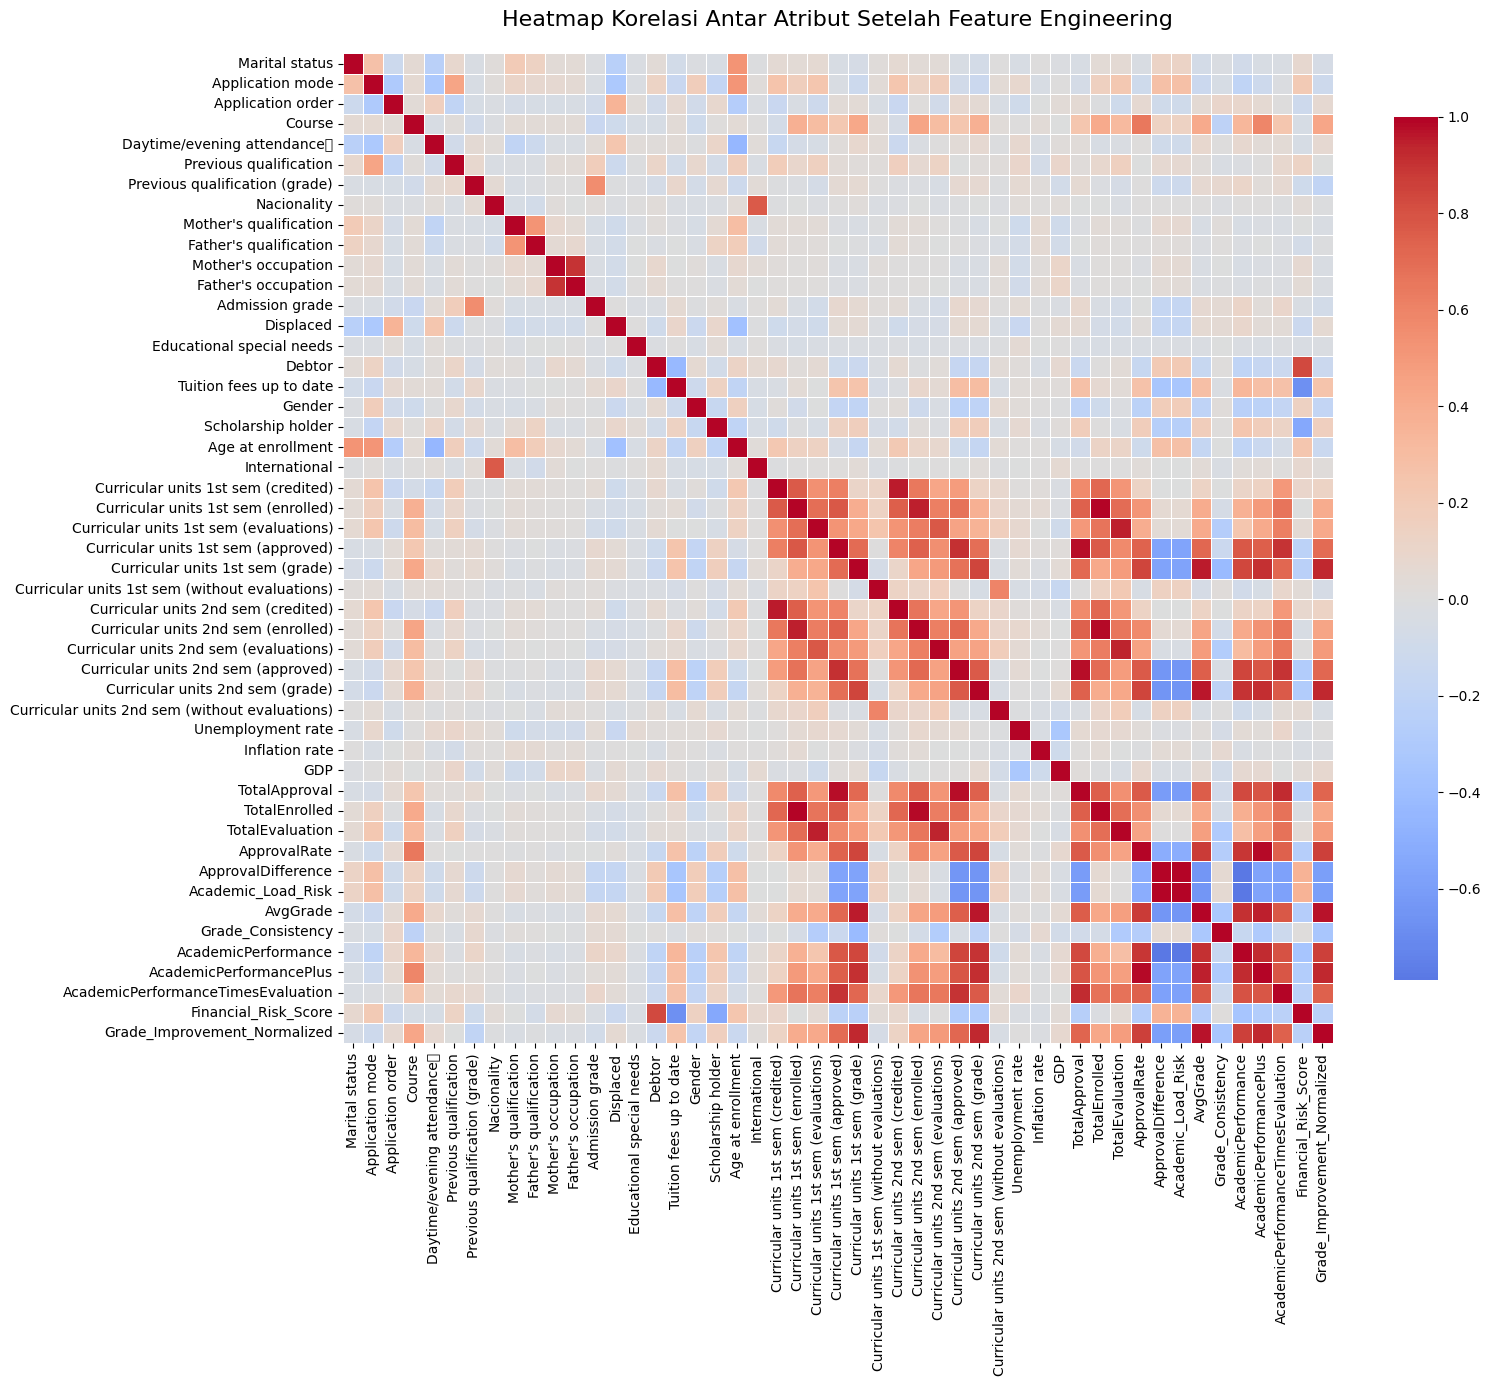

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

X_numeric = X_train_fe.select_dtypes(include=['int64', 'float64']).copy()
print(f"Numeric features shape: {X_numeric.shape}")
print(f"Numeric columns: {X_numeric.columns.tolist()[:10]}...")

correlation_matrix = X_numeric.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, square=True)
plt.title('Heatmap Korelasi Antar Atribut Setelah Feature Engineering', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

**Explanation:** Feature engineering membuat 12 features baru yang lebih informatif, dikelompokkan berdasarkan kategori:

**Basic Features (3):**
- TotalApproval: Total unit yang disetujui dari kedua semester
- TotalEnrolled: Total unit yang didaftarkan dari kedua semester
- TotalEvaluation: Total evaluasi yang dilakukan

**Approval Metrics (3):**
- ApprovalRate: Rasio kelulusan untuk mengukur performa akademik (TotalApproval/TotalEnrolled)
- ApprovalDifference: Selisih enrolled dan approved untuk melihat unit yang tidak lulus
- Academic_Load_Risk: Jumlah unit yang gagal, indikator beban akademik yang berisiko

**Grade Metrics (2):**
- AvgGrade: Rata-rata nilai semester 1 dan 2
- Grade_Consistency: Konsistensi nilai antar semester (nilai lebih tinggi = lebih konsisten)

**Combined Performance (3):**
- AcademicPerformance: Kombinasi approval rate dengan normalized grade (perkalian)
- AcademicPerformancePlus: Alternatif perhitungan performa akademik (penjumlahan)
- AcademicPerformanceTimesEvaluation: Performa dikalikan jumlah evaluasi

**Financial Risk (1):**
- Financial_Risk_Score: Skor risiko finansial berdasarkan tunggakan, status debtor, dan beasiswa (nilai lebih tinggi = risiko lebih tinggi)

**Atribut to Drop**

In [10]:
ListColumnToDrop = [
    # ============================================================================
    # ORIGINAL SEMESTER COLUMNS (redundant after creating Total features)
    # ============================================================================
    # 'Curricular units 1st sem (approved)',
    # 'Curricular units 2nd sem (approved)',
    # 'Curricular units 1st sem (enrolled)',
    # 'Curricular units 2nd sem (enrolled)',
    # 'Curricular units 1st sem (evaluations)',
    # 'Curricular units 2nd sem (evaluations)',
    
    # ============================================================================
    # ENGINEERED FEATURES (FE1-FE12)
    # ============================================================================
    'TotalApproval',  # FE1
    'TotalEnrolled',  # FE2
    'TotalEvaluation',  # FE3
    'ApprovalRate',  # FE4
    # 'ApprovalDifference',  # FE5 - Same as Academic_Load_Risk
    'Academic_Load_Risk',  # FE6
    # 'AvgGrade',  # FE7
    # 'Grade_Consistency',  # FE8
    'AcademicPerformance',  # FE9
    'AcademicPerformancePlus',  # FE10 - Alternative version
    # 'AcademicPerformanceTimesEvaluation',  # FE11
    # 'Financial_Risk_Score',  # FE12
    
    # ============================================================================
    # CATEGORICAL COLUMNS (uncomment if not useful)
    # ============================================================================
    'Marital status',
    # 'Application mode',
    # 'Application order',
    # 'Course',
    # 'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    # "Mother's occupation",
    # "Father's occupation",
    # 'Educational special needs',
    'International',
    # 'Debtor',
    # 'Tuition fees up to date',
    # 'Scholarship holder',
    # 'Displaced',
    'Gender',
    
    # ============================================================================
    # CONTINUOUS COLUMNS (uncomment if not useful)
    # ============================================================================
    # 'Previous qualification (grade)',
    # 'Admission grade',
    # 'Age at enrollment',
    # 'Curricular units 1st sem (credited)',
    # 'Curricular units 1st sem (grade)',
    # 'Curricular units 1st sem (without evaluations)',
    # 'Curricular units 2nd sem (credited)',
    # 'Curricular units 2nd sem (grade)',
    # 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    # 'Inflation rate'
    # 'GDP',
]

print(f"Columns to drop: {len(ListColumnToDrop)}")
print(f"Columns: {ListColumnToDrop}")

if len(ListColumnToDrop) > 0:
    X_train_fe = X_train_fe.drop(columns=ListColumnToDrop)
    X_val_fe = X_val_fe.drop(columns=ListColumnToDrop)
    print(f"\nAfter dropping columns:")
    print(f"Training shape: {X_train_fe.shape}")
    print(f"Validation shape: {X_val_fe.shape}")
else:
    print("\nNo columns to drop (all commented out)")

Columns to drop: 14
Columns: ['TotalApproval', 'TotalEnrolled', 'TotalEvaluation', 'ApprovalRate', 'Academic_Load_Risk', 'AcademicPerformance', 'AcademicPerformancePlus', 'Marital status', 'Nacionality', "Mother's qualification", "Father's qualification", 'International', 'Gender', 'Unemployment rate']

After dropping columns:
Training shape: (2476, 35)
Validation shape: (620, 35)


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [11]:
# Example

# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEncoder(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):

#         # Fit the encoder here

#         return self

#     def transform(self, X):
#         X_encoded = X.copy()

#         # Encode the categorical variables here

#         return X_encoded

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [12]:
print("Skipping feature scaling for Decision Tree model")

Skipping feature scaling for Decision Tree model


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [13]:
existing_cat_cols = [col for col in categorical_cols if col in X_train_fe.columns]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_encoded = encoder.fit_transform(X_train_fe[existing_cat_cols])
X_val_encoded = encoder.transform(X_val_fe[existing_cat_cols])

encoded_feature_names = encoder.get_feature_names_out(existing_cat_cols)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train_fe.index)
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoded_feature_names, index=X_val_fe.index)

X_train_final = X_train_fe.drop(columns=existing_cat_cols).join(X_train_encoded_df).reset_index(drop=True)
X_val_final = X_val_fe.drop(columns=existing_cat_cols).join(X_val_encoded_df).reset_index(drop=True)

# Reset y_train and y_val indices to match
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

print(f"Encoding completed")
print(f"Training shape after encoding: {X_train_final.shape}")
print(f"Validation shape after encoding: {X_val_final.shape}")

Encoding completed
Training shape after encoding: (2476, 159)
Validation shape after encoding: (620, 159)


**Explanation:** One-Hot Encoding digunakan untuk categorical features karena tidak ada urutan/hierarki antar kategori. Setiap kategori direpresentasikan sebagai binary column terpisah.

### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [14]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights_array))

print(f"Class weights computed:")
for cls, weight in class_weights.items():
    print(f"  {cls}: {weight:.4f}")

Class weights computed:
  0: 1.0382
  1: 0.6677
  2: 1.8547


**Explanation:** Class weights dihitung untuk menangani imbalanced dataset. Kelas minority akan diberi weight lebih besar sehingga model tidak bias ke kelas majority.

### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [15]:
print("Skipping data normalization")

Skipping data normalization


### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [16]:
print("Skipping dimensionality reduction")

Skipping dimensionality reduction


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [17]:
# from sklearn.pipeline import Pipeline

# # Note: You can add or delete preprocessing components from this pipeline

# pipe = Pipeline([("imputer", FeatureImputer()),
#                  ("featurecreator", FeatureCreator()),
#                  ("scaler", FeatureScaler()),
#                  ("encoder", FeatureEncoder())])

# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

In [18]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

or create your own here

In [19]:
print("Preprocessing pipeline completed")
print(f"Final training set shape: {X_train_final.shape}")
print(f"Final validation set shape: {X_val_final.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Validation target shape: {y_val.shape}")
print(f"\nReady for modeling")

Preprocessing pipeline completed
Final training set shape: (2476, 159)
Final validation set shape: (620, 159)
Training target shape: (2476,)
Validation target shape: (620,)

Ready for modeling


# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [20]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None, gain=None, 
                 split_type='binary', children=None, split_values=None):
        self.feature = feature
        self.threshold = threshold  # For binary splits
        self.left = left  # For binary splits
        self.right = right  # For binary splits
        self.value = value  # For leaf nodes
        self.gain = gain
        
        # For multi-way splits
        self.split_type = split_type  # 'binary' or 'multiway'
        self.children = children if children is not None else {}  # Dictionary: split_value -> child_node
        self.split_values = split_values  # List of values for multi-way split
    
    def is_leaf(self):
        return self.value is not None

In [21]:
class DecisionTreeC45:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, class_weight=None,
                 enable_multiway_splits=True, max_bins=6):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.class_weight = class_weight
        self.enable_multiway_splits = enable_multiway_splits
        self.max_bins = max_bins
        self.root = None
        self.feature_names = None
        self.n_features = None
        self.feature_types = None
        
    def entropy(self, y):
        classes, counts = np.unique(y, return_counts=True)
        
        if self.class_weight is not None:
            weighted_counts = np.array([counts[i] * self.class_weight.get(classes[i], 1.0) 
                                       for i in range(len(classes))])
            probabilities = weighted_counts / weighted_counts.sum()
        else:
            probabilities = counts / counts.sum()
        
        return -np.sum([p * np.log2(p) for p in probabilities if p > 0])
    
    def split_info(self, splits, y):
        # hitung split info untuk multi-way splits
        n = len(y)
        split_info_value = 0
        
        for split_data in splits.values():
            if len(split_data) == 0:
                continue
            p = len(split_data) / n
            if p > 0:
                split_info_value -= p * np.log2(p)
        
        return split_info_value
    
    def information_gain_multiway(self, y, splits):
        # hitung information gain untuk multi-way splits
        parent_entropy = self.entropy(y)
        n = len(y)
        
        weighted_entropy = 0
        for split_data in splits.values():
            if len(split_data) == 0:
                continue
            weight = len(split_data) / n
            weighted_entropy += weight * self.entropy(split_data)
        
        return parent_entropy - weighted_entropy
    
    def gain_ratio_multiway(self, y, splits):
        # hitung gain ratio untuk multi-way splits
        ig = self.information_gain_multiway(y, splits)
        si = self.split_info(splits, y)
        
        if si == 0:
            return 0
        
        return ig / si
    
    def find_best_split_points(self, X_column, y, max_splits=4):
        # cari titik split terbaik dengan entropy
        unique_values = np.unique(X_column)
        
        if len(unique_values) <= 2:
            return None
        
        sorted_indices = np.argsort(X_column)
        X_sorted = X_column[sorted_indices]
        y_sorted = y[sorted_indices]
        
        candidate_points = []
        for i in range(len(unique_values) - 1):
            split_point = (unique_values[i] + unique_values[i + 1]) / 2
            candidate_points.append(split_point)
        
        if len(candidate_points) == 0:
            return None
        
        # Try different numbers of splits (2 to max_splits)
        best_splits = None
        best_splits = None
        best_gain = -1
        
        for n_splits in range(2, min(max_splits + 1, len(candidate_points) + 1)):
            split_points = self._find_n_best_splits(X_sorted, y_sorted, n_splits)
            
            if split_points is None or len(split_points) == 0:
                continue
            
            regions = self._create_regions_from_splits(X_column, y, split_points)
            gain = self.information_gain_multiway(y, regions)
            
            if gain > best_gain:
                best_gain = gain
                best_splits = split_points
        
        if best_splits is None or len(best_splits) == 0:
            return None
        
        # Create final bins with labels
        bins, bin_edges = self._create_bins_from_splits(X_column, y, best_splits)
        return bins, bin_edges, best_gain
    
    def _find_n_best_splits(self, X_sorted, y_sorted, n_splits):
        bins, bin_edges = self._create_bins_from_splits(X_column, y, best_splits)
        return bins, bin_edges, best_gain
    
    def _find_n_best_splits(self, X_sorted, y_sorted, n_splits):
        # cari n titik split terbaik dengan reduksi entropy
        if n_splits <= 0 or len(X_sorted) < n_splits + 1:
            return None
        
        split_points = []
        regions = [(0, len(X_sorted))]
        
        for _ in range(n_splits):
            best_split_pos = None
            best_split_value = None
            best_entropy_reduction = -1
            best_region_idx = None
            
            for region_idx, (start, end) in enumerate(regions):
                if end - start < 2 * self.min_samples_leaf:
                    continue
                
                region_y = y_sorted[start:end]
                region_X = X_sorted[start:end]
                
                for i in range(start + self.min_samples_leaf, end - self.min_samples_leaf):
                    if X_sorted[i] == X_sorted[i - 1]:
                        continue
                    
                    left_y = y_sorted[start:i]
                    right_y = y_sorted[i:end]
                    
                    parent_entropy = self.entropy(region_y)
                    n = len(region_y)
                    weighted_entropy = (len(left_y) / n) * self.entropy(left_y) + \
                                     (len(right_y) / n) * self.entropy(right_y)
                    entropy_reduction = parent_entropy - weighted_entropy
                    
                    if entropy_reduction > best_entropy_reduction:
                        best_entropy_reduction = entropy_reduction
                        best_split_pos = i
                        best_split_value = (X_sorted[i - 1] + X_sorted[i]) / 2
                        best_region_idx = region_idx
            
            if best_split_pos is None:
                break
            
            split_points.append(best_split_value)
            
            old_start, old_end = regions[best_region_idx]
            regions[best_region_idx] = (old_start, best_split_pos)
            regions.insert(best_region_idx + 1, (best_split_pos, old_end))
        
        return sorted(split_points) if len(split_points) > 0 else None
    
    def _create_regions_from_splits(self, X_column, y, split_points):
        # buat regions dari split points
        regions = {}
        split_points_sorted = sorted(split_points)
        
        mask = X_column <= split_points_sorted[0]
        regions[f"≤{split_points_sorted[0]:.2f}"] = y[mask]
        
        for i in range(len(split_points_sorted) - 1):
            mask = (X_column > split_points_sorted[i]) & (X_column <= split_points_sorted[i + 1])
            regions[f"({split_points_sorted[i]:.2f},{split_points_sorted[i+1]:.2f}]"] = y[mask]
        
        mask = X_column > split_points_sorted[-1]
        regions[f">{split_points_sorted[-1]:.2f}"] = y[mask]
        
        return regions
    
    def _create_bins_from_splits(self, X_column, y, split_points):
        # buat bins dan edges dari split points
        split_points_sorted = sorted(split_points)
        bins = self._create_regions_from_splits(X_column, y, split_points_sorted)
        bin_edges = [X_column.min()] + split_points_sorted + [X_column.max()]
        return bins, np.array(bin_edges)
    
    def discretize_feature(self, X_column, y):
        # diskretisasi fitur continuous dengan multi-way splitting
        result = self.find_best_split_points(X_column, y, max_splits=self.max_bins - 1)
        
        if result is None:
            return None
        
        bins, bin_edges, gain = result
        
        if len(bins) <= 2:
            return None
        
        return bins, bin_edges
    
    def best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        best_splits = None
        best_bin_edges = None
        best_split_type = 'binary'
        
        n_features = X.shape[1]
        
        if self.enable_multiway_splits:
            multiway_feature, multiway_splits, multiway_edges, multiway_gain, is_categorical = \
                self.best_multiway_split(X, y)
            
            if multiway_splits is not None and len(multiway_splits) >= 3:
                best_gain = multiway_gain
                best_feature = multiway_feature
                best_splits = multiway_splits
                best_bin_edges = multiway_edges
                best_split_type = 'multiway'
        
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                gain = self.gain_ratio(y, y_left, y_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
                    best_splits = None
                    best_bin_edges = None
                    best_split_type = 'binary'
        
        return best_feature, best_threshold, best_splits, best_bin_edges, best_gain, best_split_type
    
    def best_multiway_split(self, X, y):
        """Find best multi-way split across all features"""
        best_gain = -1
        best_feature = None
        best_splits = None
        best_bin_edges = None
        best_is_categorical = False
        
        n_features = X.shape[1]
        
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            n_unique = len(np.unique(X_column))
            
            # Check if feature is categorical (encoded as integers, small number of unique values)
            is_categorical = n_unique <= 20  # Heuristic: ≤20 unique values = categorical
            
            if is_categorical and self.enable_multiway_splits:
                # Multi-way split for categorical features
                unique_values = np.unique(X_column)
                
                if len(unique_values) <= 1:
                    continue
                
                splits = {}
                for val in unique_values:
                    mask = X_column == val
                    splits[f"={val:.0f}"] = y[mask]
                
                # Check if all splits have minimum samples
                if any(len(split_y) < self.min_samples_leaf for split_y in splits.values()):
                    continue
                    continue
                gain = self.gain_ratio_multiway(y, splits)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_splits = splits
                    best_bin_edges = unique_values
                    best_is_categorical = True
            
            # Try discretization for continuous features
            if not is_categorical and self.enable_multiway_splits:
                discretize_result = self.discretize_feature(X_column, y)
                
                if discretize_result is not None:
                    bins, bin_edges = discretize_result
                    
                    # Check if all bins have minimum samples
                    if any(len(bin_y) < self.min_samples_leaf for bin_y in bins.values()):
                        continue
                        continue
                    gain = self.gain_ratio_multiway(y, bins)
                    
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature_idx
                        best_splits = bins
                        best_bin_edges = bin_edges
                        best_is_categorical = False
        
        return best_feature, best_splits, best_bin_edges, best_gain, best_is_categorical
    
    def information_gain(self, y, y_left, y_right):
        parent_entropy = self.entropy(y)
        n = len(y)
        n_left, n_right = len(y_left), len(y_right)
        
        if n_left == 0 or n_right == 0:
            return 0
        
        child_entropy = (n_left / n) * self.entropy(y_left) + (n_right / n) * self.entropy(y_right)
        ig = parent_entropy - child_entropy
        return ig
    
    def gain_ratio(self, y, y_left, y_right):
        ig = self.information_gain(y, y_left, y_right)
        n = len(y)
        n_left = len(y_left)
        n_right = len(y_right)
        
        if n_left == 0 or n_right == 0:
            return 0
        
        # Split info for binary split
        si = -(n_left/n) * np.log2(n_left/n) - (n_right/n) * np.log2(n_right/n)
        
        if si == 0:
            return 0
        
        return ig / si
    
    def best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        best_splits = None
        best_bin_edges = None
        best_split_type = 'binary'
        multiway_gain_threshold = 0.0  # Multi-way must be significantly better
        
        n_features = X.shape[1]
        
        # Try binary splits for all features first
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)
            
            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) < self.min_samples_leaf or np.sum(right_mask) < self.min_samples_leaf:
                    continue
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                # Calculate gain ratio for binary split
                gain = self.gain_ratio(y, y_left, y_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
                    best_splits = None
                    best_bin_edges = None
                    best_split_type = 'binary'
        
        # Only try multi-way splits if enabled and no good binary split found
        if self.enable_multiway_splits and best_gain < 0.1:  # Only if binary split is weak
            multiway_feature, multiway_splits, multiway_edges, multiway_gain, is_categorical = \
                self.best_multiway_split(X, y)
            
            # Multi-way split must be significantly better (10% improvement)
            if multiway_gain > best_gain * (1 + multiway_gain_threshold) and multiway_splits is not None:
                if len(multiway_splits) <= 4:  # Limit branches to avoid overfitting
                    best_gain = multiway_gain
                    best_feature = multiway_feature
                    best_splits = multiway_splits
                    best_bin_edges = multiway_edges
                    best_split_type = 'multiway'
        
        return best_feature, best_threshold, best_splits, best_bin_edges, best_gain, best_split_type
    
    def build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        if depth >= self.max_depth or n_classes == 1 or n_samples < self.min_samples_split:
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)
        
        best_feature, best_threshold, best_splits, best_bin_edges, best_gain, split_type = \
        self.best_split(X, y)
        
        if best_feature is None:
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)
        
        if split_type == 'binary':
            # Binary split
            left_mask = X[:, best_feature] <= best_threshold
            right_mask = ~left_mask
            
            left_child = self.build_tree(X[left_mask], y[left_mask], depth + 1)
            right_child = self.build_tree(X[right_mask], y[right_mask], depth + 1)
            
            return Node(feature=best_feature, threshold=best_threshold, 
                       left=left_child, right=right_child, gain=best_gain, split_type='binary')
        
        else:
            # Multi-way split
            children = {}
            X_column = X[:, best_feature]
            
            for split_label in best_splits.keys():
                mask = None
                
                if '=' in split_label:
                    # Categorical split: =value
                    val = float(split_label.split('=')[1])
                    mask = X_column == val
                
                elif split_label.startswith('≤'):
                    # First region: ≤x
                    val = float(split_label[1:])
                    mask = X_column <= val
                
                elif split_label.startswith('>'):
                    # Last region: >x
                    val = float(split_label[1:])
                    mask = X_column > val
                
                elif '(' in split_label and ']' in split_label:
                    # Middle region: (x,y]
                    range_str = split_label.strip('()[]').split(',')
                    lower = float(range_str[0])
                    upper = float(range_str[1])
                    mask = (X_column > lower) & (X_column <= upper)
                
                elif '[' in split_label and ')' in split_label:
                    # Old format support: [x,y)
                    range_str = split_label.strip('[]()').split(',')
                    lower = float(range_str[0])
                    upper = float(range_str[1])
                    
                    # Find index of this bin
                    bin_idx = list(best_splits.keys()).index(split_label)
                    
                    if bin_idx == len(best_splits) - 1:
                        mask = (X_column >= lower) & (X_column <= upper)
                    else:
                        mask = (X_column >= lower) & (X_column < upper)
                
                if mask is not None and np.sum(mask) > 0:
                    child = self.build_tree(X[mask], y[mask], depth + 1)
                    children[split_label] = child
            
            return Node(feature=best_feature, gain=best_gain, split_type='multiway',
                       children=children, split_values=list(best_splits.keys()))
    
    def most_common_label(self, y):
        if self.class_weight is not None:
            classes, counts = np.unique(y, return_counts=True)
            weighted_counts = np.array([counts[i] * self.class_weight.get(classes[i], 1.0) 
                                       for i in range(len(classes))])
            return classes[np.argmax(weighted_counts)]
        else:
            return np.bincount(y).argmax()
    
    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values
        else:
            self.feature_names = [f"feature_{i}" for i in range(X.shape[1])]
        
        self.n_features = X.shape[1]
        self.root = self.build_tree(X, y)
        return self
    
    def predict_sample(self, x, node):
        if node.is_leaf():
            return node.value
        
        if node.split_type == 'binary':
            # Binary split
            if x[node.feature] <= node.threshold:
                return self.predict_sample(x, node.left)
            else:
                return self.predict_sample(x, node.right)
        
        else:
            # Multi-way split
            X_val = x[node.feature]
            
            # Find matching child
            for split_label, child in node.children.items():
                if '=' in split_label:
                    # Categorical split
                    val = float(split_label.split('=')[1])
                    if X_val == val:
                        return self.predict_sample(x, child)
                
                elif split_label.startswith('≤'):
                    # First region: ≤x
                    val = float(split_label[1:])
                    if X_val <= val:
                        return self.predict_sample(x, child)
                
                elif split_label.startswith('>'):
                    # Last region: >x
                    val = float(split_label[1:])
                    if X_val > val:
                        return self.predict_sample(x, child)
                
                elif '(' in split_label and ']' in split_label:
                    # Middle region: (x,y]
                    range_str = split_label.strip('()[]').split(',')
                    lower = float(range_str[0])
                    upper = float(range_str[1])
                    if lower < X_val <= upper:
                        return self.predict_sample(x, child)
                
                elif '[' in split_label:
                    # Old format support: [x,y)
                    range_str = split_label.strip('[]()').split(',')
                    lower = float(range_str[0])
                    upper = float(range_str[1])
                    
                    # Check if last bin (includes upper bound)
                    bin_idx = list(node.children.keys()).index(split_label)
                    
                    if bin_idx == len(node.children) - 1:
                        if lower <= X_val <= upper:
                            return self.predict_sample(x, child)
                    else:
                        if lower <= X_val < upper:
                            return self.predict_sample(x, child)
            
            # Default: return most common label if no match found
            return node.value if hasattr(node, 'value') and node.value is not None else 0
    
    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return np.array([self.predict_sample(x, self.root) for x in X])
    
    def print_tree(self, node=None, depth=0, prefix="", is_last=True, parent_prefix=""):
        if node is None:
            node = self.root
            print("\n" + "="*80)
            print("DECISION TREE STRUCTURE")
            print("="*80)
        
        # Create tree branch visualization
        if depth == 0:
            branch = "Root"
        else:
            branch = parent_prefix + ("└── " if is_last else "├── ")
        
        if node.is_leaf():
            print(f"{branch} Leaf: Class={node.value}")
        elif node.split_type == 'binary':
            feature_name = self.feature_names[node.feature] if self.feature_names else f"X[{node.feature}]"
            print(f"{branch} {feature_name} <= {node.threshold:.4f} (Gain: {node.gain:.4f})")
            
            # Prepare prefix for children
            child_prefix = parent_prefix + ("    " if is_last else "│   ") if depth > 0 else ""
            
            if node.left and node.right:
                self.print_tree(node.left, depth + 1, "≤ True  ", False, child_prefix)
                self.print_tree(node.right, depth + 1, "≤ False ", True, child_prefix)
            elif node.left:
                self.print_tree(node.left, depth + 1, "≤ True  ", True, child_prefix)
            elif node.right:
                self.print_tree(node.right, depth + 1, "≤ False ", True, child_prefix)
        else:
            # Multi-way split
            feature_name = self.feature_names[node.feature] if self.feature_names else f"X[{node.feature}]"
            print(f"{branch} {feature_name} (Multi-way, {len(node.children)} branches, Gain: {node.gain:.4f})")
            
            child_prefix = parent_prefix + ("    " if is_last else "│   ") if depth > 0 else ""
            
            children_list = list(node.children.items())
            for i, (split_label, child) in enumerate(children_list):
                is_last_child = (i == len(children_list) - 1)
                self.print_tree(child, depth + 1, f"{split_label} ", is_last_child, child_prefix)
        
        if depth == 0:
            print("="*80)
    
    def get_depth(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 0
        
        if node.split_type == 'binary':
            left_depth = self.get_depth(node.left) if node.left else 0
            right_depth = self.get_depth(node.right) if node.right else 0
            return 1 + max(left_depth, right_depth)
        else:
            # Multi-way split
            max_child_depth = 0
            for child in node.children.values():
                child_depth = self.get_depth(child)
                max_child_depth = max(max_child_depth, child_depth)
            return 1 + max_child_depth
    
    def count_nodes(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 1
        
        if node.split_type == 'binary':
            left_count = self.count_nodes(node.left) if node.left else 0
            right_count = self.count_nodes(node.right) if node.right else 0
            return 1 + left_count + right_count
        else:
            # Multi-way split
            total_count = 1
            for child in node.children.values():
                total_count += self.count_nodes(child)
            return total_count
    
    def count_leaves(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 1
        
        if node.split_type == 'binary':
            left_leaves = self.count_leaves(node.left) if node.left else 0
            right_leaves = self.count_leaves(node.right) if node.right else 0
            return left_leaves + right_leaves
        else:
            # Multi-way split
            total_leaves = 0
            for child in node.children.values():
                total_leaves += self.count_leaves(child)
            return total_leaves


## HIERARCHICAL CLASSIFICATION APPROACH

**Strategy:**
1. **Tree 1 (Dropout vs Non-Dropout)**: Pisahkan 'Dropout' dari yang lainnya ('Graduate' + 'Enrolled')
2. **Tree 2 (Graduate vs Enrolled)**: Untuk yang Non-Dropout, pisahkan 'Graduate' dari 'Enrolled'

**Reason**: Most of 'Enrolled' are expected to become 'Graduate', so we separate dropout detection first, then distinguish between graduate and enrolled.

In [22]:
print("hierarchical decision tree training")
print("step 1: training tree 1 - dropout vs non-dropout")

# buat binary labels untuk tree 1
y_train_binary = np.where(y_train == 0, 0, 1).astype(int)
y_val_binary = np.where(y_val == 0, 0, 1).astype(int)

# hitung class weights untuk binary classification
classes_binary = np.unique(y_train_binary)
weights_binary = compute_class_weight('balanced', classes=classes_binary, y=y_train_binary)
class_weights_binary = dict(zip(classes_binary, weights_binary))

print(f"dropout: {np.sum(y_train_binary == 0)}, non-dropout: {np.sum(y_train_binary == 1)}")

# train tree 1
tree1_model = DecisionTreeC45(
    max_depth=10, 
    min_samples_split=5, 
    min_samples_leaf=2, 
    class_weight=class_weights_binary, 
    enable_multiway_splits=True, 
    max_bins=6
)
tree1_model.fit(X_train_final, y_train_binary)

y_train_tree1 = tree1_model.predict(X_train_final)
y_val_tree1 = tree1_model.predict(X_val_final)
tree1_train_acc = np.mean(y_train_tree1 == y_train_binary)
tree1_val_acc = np.mean(y_val_tree1 == y_val_binary)

print(f"tree 1 - depth: {tree1_model.get_depth()}, nodes: {tree1_model.count_nodes()}")
print(f"tree 1 - train acc: {tree1_train_acc:.4f}, val acc: {tree1_val_acc:.4f}")

print("\nstep 2: training tree 2 - graduate vs enrolled")

# filter non-dropout samples untuk tree 2
train_nondropout_mask = y_train != 0
val_nondropout_mask = y_val != 0

X_train_nondropout = X_train_final[train_nondropout_mask].reset_index(drop=True)
y_train_nondropout = y_train[train_nondropout_mask].values

X_val_nondropout = X_val_final[val_nondropout_mask].reset_index(drop=True)
y_val_nondropout = y_val[val_nondropout_mask].values

print(f"graduate: {np.sum(y_train_nondropout == 1)}, enrolled: {np.sum(y_train_nondropout == 2)}")

# hitung class weights untuk graduate vs enrolled
classes_nondropout = np.unique(y_train_nondropout)
weights_nondropout = compute_class_weight('balanced', classes=classes_nondropout, y=y_train_nondropout)
class_weights_nondropout = dict(zip(classes_nondropout, weights_nondropout))

# train tree 2
tree2_model = DecisionTreeC45(
    max_depth=10, 
    min_samples_split=5, 
    min_samples_leaf=2, 
    class_weight=class_weights_nondropout, 
    enable_multiway_splits=True, 
    max_bins=6
)
tree2_model.fit(X_train_nondropout, y_train_nondropout)

y_train_tree2_nondropout = tree2_model.predict(X_train_nondropout)
y_val_tree2_nondropout = tree2_model.predict(X_val_nondropout)
tree2_train_acc = np.mean(y_train_tree2_nondropout == y_train_nondropout)
tree2_val_acc = np.mean(y_val_tree2_nondropout == y_val_nondropout)

print(f"tree 2 - depth: {tree2_model.get_depth()}, nodes: {tree2_model.count_nodes()}")
print(f"tree 2 - train acc: {tree2_train_acc:.4f}, val acc: {tree2_val_acc:.4f}")

print("\nstep 3: hierarchical prediction")

def hierarchical_predict(X, tree1, tree2):
    """prediksi hierarchical menggunakan dua tree"""
    tree1_pred = tree1.predict(X)
    final_pred = np.zeros(len(tree1_pred), dtype=int)
    
    dropout_mask = (tree1_pred == 0)
    final_pred[dropout_mask] = 0
    
    nondropout_mask = (tree1_pred == 1)
    if np.sum(nondropout_mask) > 0:
        X_nondropout = X[nondropout_mask]
        tree2_pred = tree2.predict(X_nondropout)
        tree2_pred = np.asarray(tree2_pred, dtype=int)
        final_pred[nondropout_mask] = tree2_pred
    
    return final_pred

y_train_pred = hierarchical_predict(X_train_final, tree1_model, tree2_model)
y_val_pred = hierarchical_predict(X_val_final, tree1_model, tree2_model)

train_accuracy = np.mean(y_train_pred == y_train)
val_accuracy = np.mean(y_val_pred == y_val)

print(f"overall - train acc: {train_accuracy:.4f}, val acc: {val_accuracy:.4f}")

hierarchical decision tree training
step 1: training tree 1 - dropout vs non-dropout
dropout: 795, non-dropout: 1681
tree 1 - depth: 10, nodes: 108
tree 1 - train acc: 0.8780, val acc: 0.8387

step 2: training tree 2 - graduate vs enrolled
graduate: 1236, enrolled: 445
tree 2 - depth: 10, nodes: 73
tree 2 - train acc: 0.8364, val acc: 0.7981

step 3: hierarchical prediction
overall - train acc: 0.7775, val acc: 0.7274


In [23]:
print("="*80)
print("TREE 1 STRUCTURE - Dropout vs Non-Dropout")
print("="*80)
tree1_model.print_tree()
print("="*80)

print("\n" + "="*80)
print("TREE 2 STRUCTURE - Graduate vs Enrolled")
print("="*80)
tree2_model.print_tree()
print("="*80)

TREE 1 STRUCTURE - Dropout vs Non-Dropout

DECISION TREE STRUCTURE
Root ApprovalDifference <= 5.0000 (Gain: 0.3360)
├──  Tuition fees up to date_0 <= 0.0000 (Gain: 0.2810)
│   ├──  AcademicPerformanceTimesEvaluation <= 5.4876 (Gain: 0.1516)
│   │   ├──  Application mode_16 <= 0.0000 (Gain: 0.1816)
│   │   │   ├──  Application order_3 <= 0.0000 (Gain: 0.1123)
│   │   │   │   ├──  Grade_Consistency (Multi-way, 1 branches, Gain: 0.3534)
│   │   │   │   │   └──  Age at enrollment <= 25.0000 (Gain: 0.1379)
│   │   │   │   │       ├──  Father's occupation_5 <= 0.0000 (Gain: 0.2166)
│   │   │   │   │       │   ├──  Admission grade <= 130.7000 (Gain: 0.1096)
│   │   │   │   │       │   │   ├──  Father's occupation_10 <= 0.0000 (Gain: 0.3338)
│   │   │   │   │       │   │   │   ├──  Leaf: Class=0
│   │   │   │   │       │   │   │   └──  Leaf: Class=1
│   │   │   │   │       │   │   └──  Admission grade <= 176.0000 (Gain: 0.2844)
│   │   │   │   │       │   │       ├──  Leaf: Class=1
│   │   │  

training set performance
confusion matrix shape: (3, 3)
confusion matrix:
[[ 689   75   31]
 [  55 1098   83]
 [ 141  166  138]]


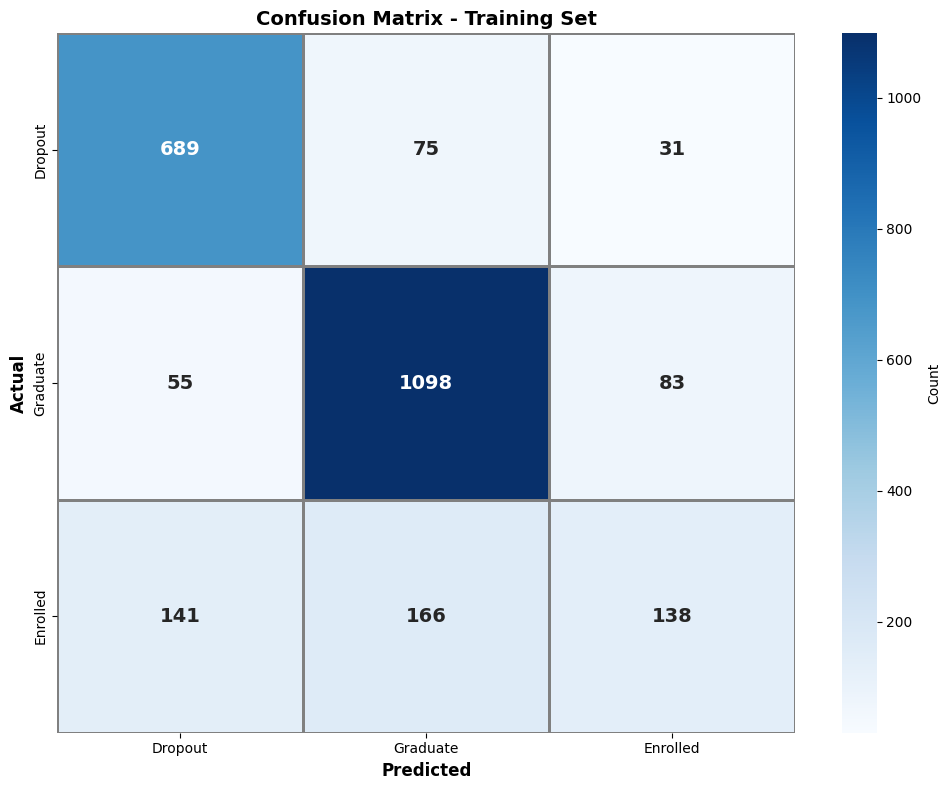


classification report:
              precision    recall  f1-score   support

     Dropout       0.78      0.87      0.82       795
    Graduate       0.82      0.89      0.85      1236
    Enrolled       0.55      0.31      0.40       445

    accuracy                           0.78      2476
   macro avg       0.72      0.69      0.69      2476
weighted avg       0.76      0.78      0.76      2476


validation set performance
confusion matrix shape: (3, 3)
confusion matrix:
[[162  24  13]
 [ 20 267  23]
 [ 43  46  22]]


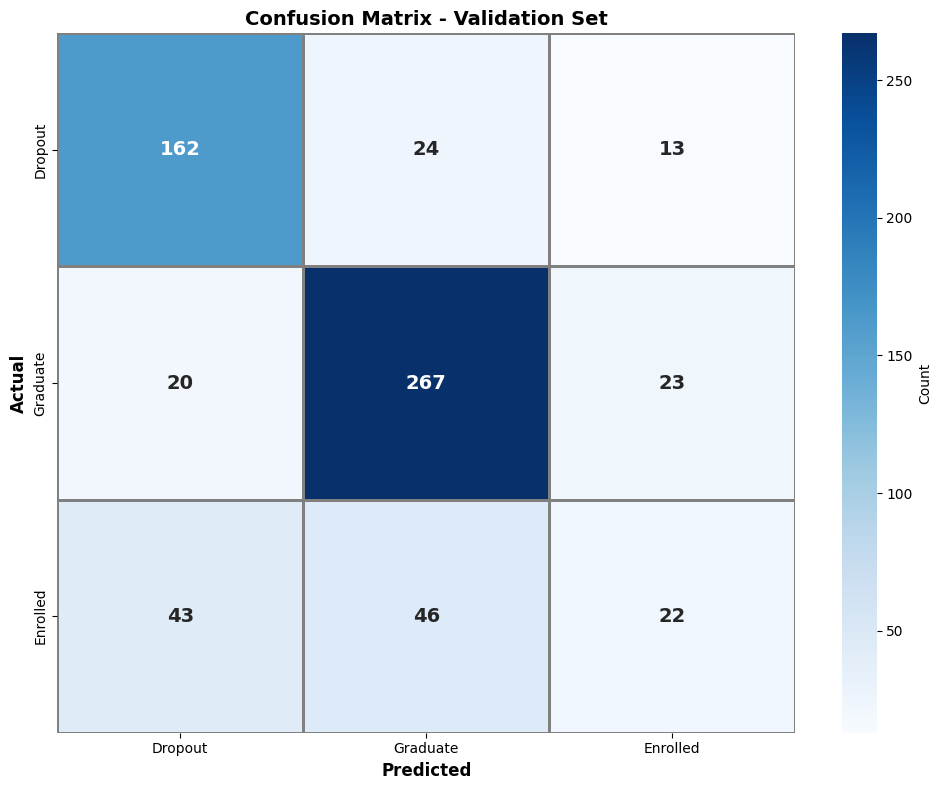


classification report:
              precision    recall  f1-score   support

     Dropout       0.72      0.81      0.76       199
    Graduate       0.79      0.86      0.83       310
    Enrolled       0.38      0.20      0.26       111

    accuracy                           0.73       620
   macro avg       0.63      0.62      0.62       620
weighted avg       0.70      0.73      0.70       620



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# label untuk confusion matrix (sesuai encoding: 0=Dropout, 1=Graduate, 2=Enrolled)
class_labels = ['Dropout', 'Graduate', 'Enrolled']

print("training set performance")
cm_train = confusion_matrix(y_train, y_train_pred, labels=[0, 1, 2])
print(f"confusion matrix shape: {cm_train.shape}")
print(f"confusion matrix:\n{cm_train}")

# heatmap confusion matrix - training
plt.figure(figsize=(10, 8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Predicted', fontsize=12, weight='bold')
plt.ylabel('Actual', fontsize=12, weight='bold')
plt.title('Confusion Matrix - Training Set', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\nclassification report:")
print(classification_report(y_train, y_train_pred, target_names=class_labels, labels=[0, 1, 2]))

print("\nvalidation set performance")
cm_val = confusion_matrix(y_val, y_val_pred, labels=[0, 1, 2])
print(f"confusion matrix shape: {cm_val.shape}")
print(f"confusion matrix:\n{cm_val}")

# heatmap confusion matrix - validation
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Predicted', fontsize=12, weight='bold')
plt.ylabel('Actual', fontsize=12, weight='bold')
plt.title('Confusion Matrix - Validation Set', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\nclassification report:")
print(classification_report(y_val, y_val_pred, target_names=class_labels, labels=[0, 1, 2]))

In [25]:
# Type your code here

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [26]:
from sklearn.metrics import f1_score

def calculate_f1_per_class(y_true, y_pred):
    classes = np.unique(y_true)
    f1_scores = {}
    
    for cls in classes:
        y_true_binary = (y_true == cls).astype(int)
        y_pred_binary = (y_pred == cls).astype(int)
        f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
        f1_scores[cls] = f1
    
    return f1_scores

print("F1 SCORE PER CLASS")
print("="*80)

print("\nTraining Set:")
f1_train = calculate_f1_per_class(y_train.values, y_train_pred)
for cls, score in f1_train.items():
    print(f"  Class {cls}: {score:.4f}")

print("\nValidation Set:")
f1_val = calculate_f1_per_class(y_val.values, y_val_pred)

macro_f1_train = np.mean(list(f1_train.values()))
macro_f1_val = np.mean(list(f1_val.values()))

print(f"macro f1 - train: {macro_f1_train:.4f}, val: {macro_f1_val:.4f}")

F1 SCORE PER CLASS

Training Set:
  Class 0: 0.8202
  Class 1: 0.8528
  Class 2: 0.3960

Validation Set:
macro f1 - train: 0.6897, val: 0.6166


In [27]:
# eksplorasi depth untuk baseline model
print("depth exploration")

depth_range = range(4, 8)
results = []

for depth in depth_range:
    model = DecisionTreeC45(max_depth=depth, min_samples_split=5, min_samples_leaf=2, 
                           class_weight=class_weights, enable_multiway_splits=True, max_bins=6)
    model.fit(X_train_final, y_train)
    
    y_train_pred_temp = model.predict(X_train_final)
    y_val_pred_temp = model.predict(X_val_final)
    
    train_acc = np.mean(y_train_pred_temp == y_train)
    val_acc = np.mean(y_val_pred_temp == y_val)
    train_f1 = f1_score(y_train, y_train_pred_temp, average='macro')
    val_f1 = f1_score(y_val, y_val_pred_temp, average='macro')
    n_nodes = model.count_nodes()
    n_leaves = model.count_leaves()
    
    results.append({
        'depth': depth,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'nodes': n_nodes,
        'leaves': n_leaves
    })
    
    print(f"depth {depth} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f} | val f1: {val_f1:.4f}")

results_df = pd.DataFrame(results)
best_by_f1 = results_df.loc[results_df['val_f1'].idxmax()]
print(f"\nbest depth: {int(best_by_f1['depth'])} | val acc: {best_by_f1['val_acc']:.4f} | val f1: {best_by_f1['val_f1']:.4f}")

depth exploration
depth 4 | train acc: 0.7553 | val acc: 0.7581 | val f1: 0.7028
depth 5 | train acc: 0.7617 | val acc: 0.7548 | val f1: 0.6980
depth 6 | train acc: 0.7670 | val acc: 0.7500 | val f1: 0.6925
depth 7 | train acc: 0.7698 | val acc: 0.7500 | val f1: 0.6918

best depth: 4 | val acc: 0.7581 | val f1: 0.7028


**FINE-Tuning Hyperparameters for Hierarchical Model**

In [28]:
# hierarchical hyperparameter tuning
print("hierarchical hyperparameter tuning")

max_depth_range = [4, 5]
min_samples_split_range = [3, 6]
min_samples_leaf_range = [2, 4]

tuning_results = []
best_val_f1 = -1
best_params = None

for max_depth in max_depth_range:
    for min_samples_split in min_samples_split_range:
        for min_samples_leaf in min_samples_leaf_range:
            if min_samples_split < 2 * min_samples_leaf:
                continue
            
            # train tree 1: dropout vs non-dropout
            tree1 = DecisionTreeC45(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                class_weight=class_weights_binary,
                enable_multiway_splits=True,
                max_bins=6
            )
            tree1.fit(X_train_final, y_train_binary)
            
            # train tree 2: graduate vs enrolled
            tree2 = DecisionTreeC45(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                class_weight=class_weights_nondropout,
                enable_multiway_splits=True,
                max_bins=6
            )
            tree2.fit(X_train_nondropout, y_train_nondropout)
            
            # prediksi hierarchical
            y_train_pred_temp = hierarchical_predict(X_train_final, tree1, tree2)
            y_val_pred_temp = hierarchical_predict(X_val_final, tree1, tree2)
            
            # hitung metrics
            train_acc = np.mean(y_train_pred_temp == y_train)
            val_acc = np.mean(y_val_pred_temp == y_val)
            train_f1 = f1_score(y_train, y_train_pred_temp, average='macro')
            val_f1 = f1_score(y_val, y_val_pred_temp, average='macro')
            overfit_gap = train_f1 - val_f1
            
            result = {
                'max_depth': max_depth,
                'min_samples_split': min_samples_split,
                'min_samples_leaf': min_samples_leaf,
                'train_acc': train_acc,
                'val_acc': val_acc,
                'train_f1': train_f1,
                'val_f1': val_f1,
                'overfit_gap': overfit_gap,
                'tree1_nodes': tree1.count_nodes(),
                'tree2_nodes': tree2.count_nodes()
            }
            tuning_results.append(result)
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_params = {
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split,
                    'min_samples_leaf': min_samples_leaf
                }
            
            print(f"depth={max_depth}, split={min_samples_split}, leaf={min_samples_leaf} | val f1={val_f1:.4f}")

# simpan hasil tuning
tuning_df = pd.DataFrame(tuning_results)
tuning_df_sorted = tuning_df.sort_values('val_f1', ascending=False)

print(f"\nbest params: depth={best_params['max_depth']}, split={best_params['min_samples_split']}, leaf={best_params['min_samples_leaf']}")
print(f"best val f1: {best_val_f1:.4f}\n")

# train model dengan best params
best_tree1 = DecisionTreeC45(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    class_weight=class_weights_binary,
    enable_multiway_splits=True,
    max_bins=6
)
best_tree1.fit(X_train_final, y_train_binary)

best_tree2 = DecisionTreeC45(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    class_weight=class_weights_nondropout,
    enable_multiway_splits=True,
    max_bins=6
)
best_tree2.fit(X_train_nondropout, y_train_nondropout)

y_train_pred_best = hierarchical_predict(X_train_final, best_tree1, best_tree2)
y_val_pred_best = hierarchical_predict(X_val_final, best_tree1, best_tree2)

train_acc_best = np.mean(y_train_pred_best == y_train)
val_acc_best = np.mean(y_val_pred_best == y_val)
train_f1_best = f1_score(y_train, y_train_pred_best, average='macro')
val_f1_best = f1_score(y_val, y_val_pred_best, average='macro')

print(f"best model - train acc: {train_acc_best:.4f}, val acc: {val_acc_best:.4f}, val f1: {val_f1_best:.4f}")

hierarchical hyperparameter tuning
depth=4, split=6, leaf=2 | val f1=0.6875
depth=5, split=6, leaf=2 | val f1=0.6890

best params: depth=5, split=6, leaf=2
best val f1: 0.6890

best model - train acc: 0.7758, val acc: 0.7581, val f1: 0.6890


**Visual Depth**

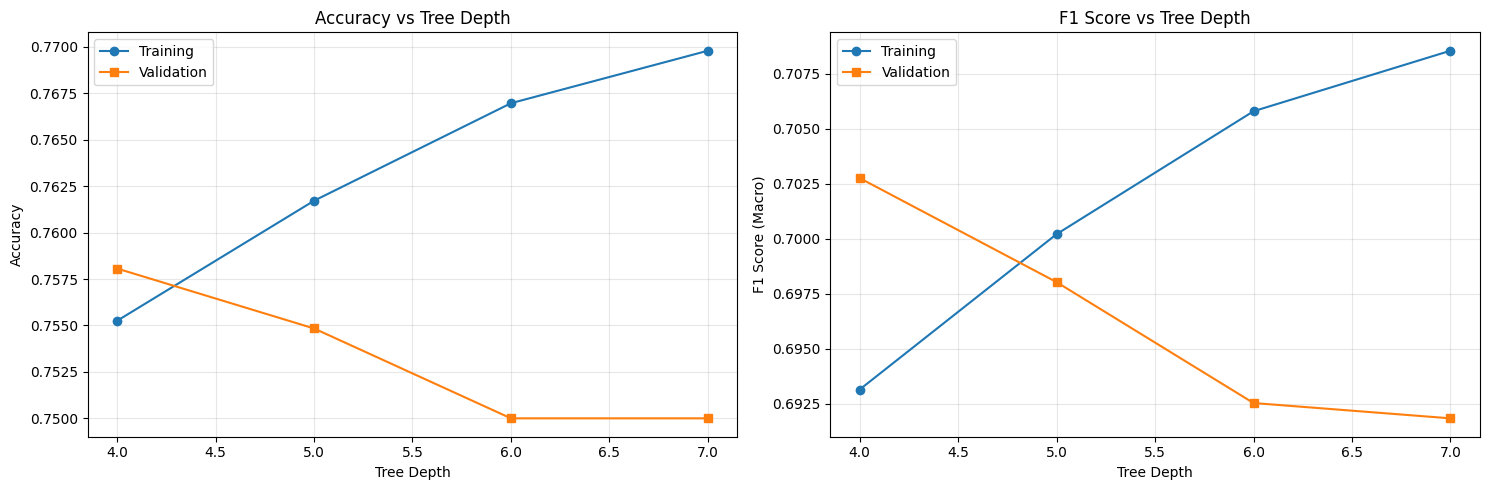

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(results_df['depth'], results_df['train_acc'], label='Training', marker='o')
axes[0].plot(results_df['depth'], results_df['val_acc'], label='Validation', marker='s')
axes[0].set_xlabel('Tree Depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Tree Depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['depth'], results_df['train_f1'], label='Training', marker='o')
axes[1].plot(results_df['depth'], results_df['val_f1'], label='Validation', marker='s')
axes[1].set_xlabel('Tree Depth')
axes[1].set_ylabel('F1 Score (Macro)')
axes[1].set_title('F1 Score vs Tree Depth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# training best model dengan 100% data (train + validation)
print("training best model dengan 100% data")
print(f"best params: depth={best_params['max_depth']}, split={best_params['min_samples_split']}, leaf={best_params['min_samples_leaf']}")

X_full = pd.concat([X_train_final, X_val_final]).reset_index(drop=True)
y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

y_full_binary = np.where(y_full == 0, 0, 1).astype(int)

classes_binary_full = np.array([0, 1])
weights_binary_full = compute_class_weight('balanced', classes=classes_binary_full, y=y_full_binary)
class_weights_binary_full = {cls: weight for cls, weight in zip(classes_binary_full, weights_binary_full)}

full_nondropout_mask = (y_full != 0)
X_full_nondropout = X_full[full_nondropout_mask].reset_index(drop=True)
y_full_nondropout = y_full[full_nondropout_mask].values

classes_nondropout_full = np.unique(y_full_nondropout)
weights_nondropout_full = compute_class_weight('balanced', classes=classes_nondropout_full, y=y_full_nondropout)
class_weights_nondropout_full = {cls: weight for cls, weight in zip(classes_nondropout_full, weights_nondropout_full)}

best_tree1 = DecisionTreeC45(
    max_depth=best_params['max_depth'], 
    min_samples_split=best_params['min_samples_split'], 
    min_samples_leaf=best_params['min_samples_leaf'],
    class_weight=class_weights_binary_full, 
    enable_multiway_splits=True, 
    max_bins=6
)
best_tree1.fit(X_full, y_full_binary)

best_tree2 = DecisionTreeC45(
    max_depth=best_params['max_depth'], 
    min_samples_split=best_params['min_samples_split'], 
    min_samples_leaf=best_params['min_samples_leaf'],
    class_weight=class_weights_nondropout_full, 
    enable_multiway_splits=True, 
    max_bins=6
)
best_tree2.fit(X_full_nondropout, y_full_nondropout)

y_full_pred = hierarchical_predict(X_full, best_tree1, best_tree2)

full_acc = np.mean(y_full_pred == y_full)
full_f1 = f1_score(y_full, y_full_pred, average='macro')

print(f"\nfinal model - acc: {full_acc:.4f}, f1: {full_f1:.4f}")
print(f"tree 1 - depth: {best_tree1.get_depth()}, nodes: {best_tree1.count_nodes()}")
print(f"tree 2 - depth: {best_tree2.get_depth()}, nodes: {best_tree2.count_nodes()}")

training best model dengan 100% data
best params: depth=5, split=6, leaf=2

final model - acc: 0.7681, f1: 0.6956
tree 1 - depth: 5, nodes: 29
tree 2 - depth: 5, nodes: 25


## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [31]:
# preprocessing test data
print("preprocessing test data")

test_df = pd.read_csv("../data/test.csv")
test_ids = test_df['Student_ID']
X_test = test_df.drop(columns=['Student_ID'])

existing_cat_cols = [col for col in categorical_cols if col in X_test.columns]
existing_cont_cols = [col for col in continuous_cols if col in X_test.columns]

if len(existing_cat_cols) > 0:
    X_test[existing_cat_cols] = imputer_cat.transform(X_test[existing_cat_cols])

if len(existing_cont_cols) > 0:
    X_test[existing_cont_cols] = imputer_num.transform(X_test[existing_cont_cols])

preprocessing test data


In [32]:
# feature engineering untuk test data
X_test['TotalApproval'] = X_test['Curricular units 1st sem (approved)'] + X_test['Curricular units 2nd sem (approved)']
X_test['TotalEnrolled'] = X_test['Curricular units 1st sem (enrolled)'] + X_test['Curricular units 2nd sem (enrolled)']
X_test['TotalEvaluation'] = X_test['Curricular units 1st sem (evaluations)'] + X_test['Curricular units 2nd sem (evaluations)']

# Approval Metrics
X_test['ApprovalRate'] = np.where(
    X_test['TotalEnrolled'] == 0,
    -1,
    X_test['TotalApproval'] / X_test['TotalEnrolled']
)
X_test['ApprovalDifference'] = X_test['TotalEnrolled'] - X_test['TotalApproval']
X_test['Academic_Load_Risk'] = X_test['TotalEnrolled'] - X_test['TotalApproval']

# Grade Metrics
X_test['AvgGrade'] = (X_test['Curricular units 1st sem (grade)'] + X_test['Curricular units 2nd sem (grade)']) / 2

grade_variance_test = np.abs(X_test['Curricular units 1st sem (grade)'] - X_test['Curricular units 2nd sem (grade)'])
X_test['Grade_Consistency'] = np.where(
    grade_variance_test > 0,
    1 / (1 + grade_variance_test),
    1.0
)

# Combined Academic Performance Metrics
max_avg_grade_test = X_test['AvgGrade'].max()
if max_avg_grade_test > 0:
    X_test['AcademicPerformance'] = X_test['ApprovalRate'] * (X_test['AvgGrade'] / max_avg_grade_test)
    X_test['AcademicPerformancePlus'] = X_test['ApprovalRate'] + (X_test['AvgGrade'] / max_avg_grade_test)
else:
    X_test['AcademicPerformance'] = 0
    X_test['AcademicPerformancePlus'] = 0

X_test['AcademicPerformanceTimesEvaluation'] = X_test['AcademicPerformance'] * X_test['TotalEvaluation']

# Financial Risk Metrics
X_test['Financial_Risk_Score'] = (
    (1 - X_test['Tuition fees up to date']) + 
    (2 * X_test['Debtor']) - 
    X_test['Scholarship holder']
)

# Grade Improvement Metrics
avg_prev_grade_test = X_test['Previous qualification (grade)'].mean()
max_prev_grade_test = X_test['Previous qualification (grade)'].max()
avg_avg_grade_test = X_test['AvgGrade'].mean()

if max_prev_grade_test > 0 and max_avg_grade_test > 0:
    X_test['Grade_Improvement_Normalized'] = (
        (X_test['AvgGrade'] - avg_avg_grade_test) / max_avg_grade_test -
        (X_test['Previous qualification (grade)'] - avg_prev_grade_test) / max_prev_grade_test
    )
else:
    X_test['Grade_Improvement_Normalized'] = 0

test_cols_to_drop = [col for col in ListColumnToDrop if col in X_test.columns]
if len(test_cols_to_drop) > 0:
    X_test = X_test.drop(columns=test_cols_to_drop)

In [33]:
# encoding test data
existing_cat_cols_test = [col for col in categorical_cols if col in X_test.columns and col in X_train_fe.columns]

X_test_encoded = encoder.transform(X_test[existing_cat_cols_test])
encoded_feature_names = encoder.get_feature_names_out(existing_cat_cols_test)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

X_test_final = X_test.drop(columns=existing_cat_cols_test).join(X_test_encoded_df)

missing_cols = set(X_train_final.columns) - set(X_test_final.columns)
if missing_cols:
    for col in missing_cols:
        X_test_final[col] = 0

extra_cols = set(X_test_final.columns) - set(X_train_final.columns)
if extra_cols:
    X_test_final = X_test_final.drop(columns=list(extra_cols))

X_test_final = X_test_final[X_train_final.columns]

In [34]:
# generate predictions untuk submission
print("generating predictions")

y_test_pred = hierarchical_predict(X_test_final, best_tree1, best_tree2)

reverse_label_mapping = {0: 'Dropout', 1: 'Graduate', 2: 'Enrolled'}
y_test_pred_labels = [reverse_label_mapping[pred] for pred in y_test_pred]

submission = pd.DataFrame({
    'Student_ID': test_ids,
    'Target': y_test_pred_labels
})

import datetime
import pickle
import os

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Save CSV submission
submission_path = f"../submission/submission_DTL_Hierarchical_{timestamp}.csv"
submission.to_csv(submission_path, index=False)

# Save model as PKL
os.makedirs("../models", exist_ok=True)
model_path = f"../models/model_DTL_Hierarchical_{timestamp}.pkl"

model_data = {
    'tree1': best_tree1,
    'tree2': best_tree2,
    'encoder': encoder,
    'imputer_cat': imputer_cat,
    'imputer_num': imputer_num,
    'feature_names': X_train_final.columns.tolist(),
    'label_mapping': label_mapping,
    'reverse_label_mapping': reverse_label_mapping,
    'best_params': best_params,
    'categorical_cols': categorical_cols,
    'continuous_cols': continuous_cols
}

with open(model_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"submission saved: {submission_path}")
print(f"model saved: {model_path}")
print(f"prediction distribution:\n{submission['Target'].value_counts().sort_index()}")

generating predictions
submission saved: ../submission/submission_DTL_Hierarchical_20251205_205103.csv
model saved: ../models/model_DTL_Hierarchical_20251205_205103.pkl
prediction distribution:
Target
Dropout     429
Enrolled    177
Graduate    722
Name: count, dtype: int64


# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`

## 6.1 SKLearn DTL


Training sklearn Decision Tree model...

Sklearn Decision Tree Results:
Training Accuracy: 0.7072
Validation Accuracy: 0.6919


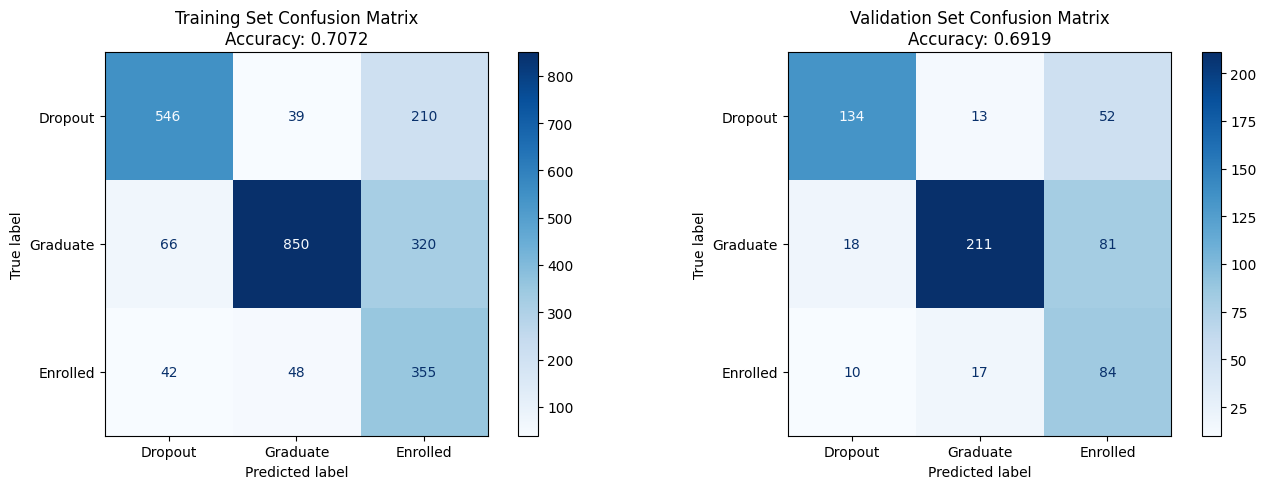


Training Confusion Matrix:
[[546  39 210]
 [ 66 850 320]
 [ 42  48 355]]

Validation Confusion Matrix:
[[134  13  52]
 [ 18 211  81]
 [ 10  17  84]]


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train sklearn Decision Tree model
print("Training sklearn Decision Tree model...")
sklearn_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

sklearn_dt.fit(X_train_final, y_train)

# Make predictions
y_train_pred_sklearn = sklearn_dt.predict(X_train_final)
y_val_pred_sklearn = sklearn_dt.predict(X_val_final)

# Calculate accuracy
train_acc_sklearn = sklearn_dt.score(X_train_final, y_train)
val_acc_sklearn = sklearn_dt.score(X_val_final, y_val)

print(f"\nSklearn Decision Tree Results:")
print(f"Training Accuracy: {train_acc_sklearn:.4f}")
print(f"Validation Accuracy: {val_acc_sklearn:.4f}")

# Create confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred_sklearn)
cm_val = confusion_matrix(y_val, y_val_pred_sklearn)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, 
                                     display_labels=['Dropout', 'Graduate', 'Enrolled'])
disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Training Set Confusion Matrix\nAccuracy: {train_acc_sklearn:.4f}')

# Validation confusion matrix
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, 
                                   display_labels=['Dropout', 'Graduate', 'Enrolled'])
disp_val.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'Validation Set Confusion Matrix\nAccuracy: {val_acc_sklearn:.4f}')

plt.tight_layout()
plt.show()

print("\nTraining Confusion Matrix:")
print(cm_train)
print("\nValidation Confusion Matrix:")
print(cm_val)